In [ ]:
!pip install qiskit qiskit_aer --quiet
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import Gate
from qiskit_aer import AerSimulator

In [ ]:
%run MvNM_base.ipynb

[True Markovian] Step 1 | S(R) ≈ 1.0000
[True Markovian] Step 2 | S(R) ≈ 2.0000


Simulating spatially separated OTOC on 10 total qubits...
This will take slightly longer due to the increased system size. Please wait...
Time t=0.00 | Re[OTOC] = 1.0000
Time t=0.32 | Re[OTOC] = 0.9990
Time t=0.63 | Re[OTOC] = 1.0000
Time t=0.95 | Re[OTOC] = 0.9912
Time t=1.26 | Re[OTOC] = 0.9873
Time t=1.58 | Re[OTOC] = 0.9883
Time t=1.89 | Re[OTOC] = 0.9873
Time t=2.21 | Re[OTOC] = 0.9736
Time t=2.53 | Re[OTOC] = 0.9639
Time t=2.84 | Re[OTOC] = 0.9570
Time t=3.16 | Re[OTOC] = 0.9443
Time t=3.47 | Re[OTOC] = 0.9131
Time t=3.79 | Re[OTOC] = 0.8477
Time t=4.11 | Re[OTOC] = 0.7266
Time t=4.42 | Re[OTOC] = 0.3691
Time t=4.74 | Re[OTOC] = -0.0020
Time t=5.05 | Re[OTOC] = -0.2383
Time t=5.37 | Re[OTOC] = -0.2842
Time t=5.68 | Re[OTOC] = -0.2598
Time t=6.00 | Re[OTOC] = -0.1592


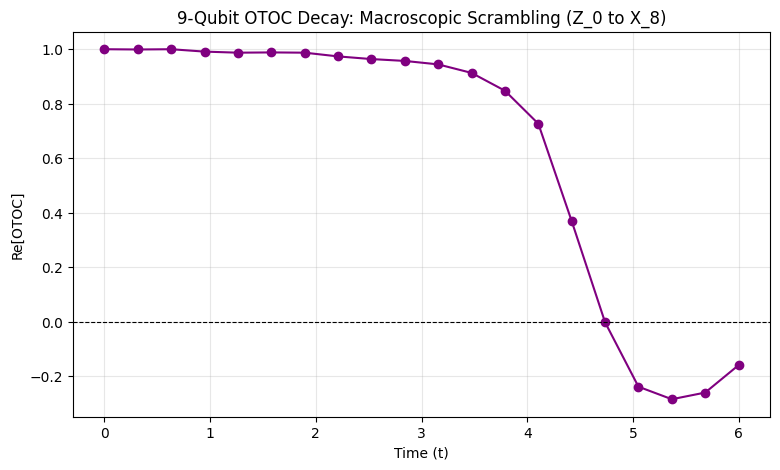

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

# 1. System Setup
num_system_qubits = 9
ancilla_qubit_index = 9  # The ancilla is now the 10th qubit (index 9)
total_qubits = 10

# 2. Hamiltonian Setup (Transverse-Field Ising Model)
J = 1.0
g = 1.05

def get_time_evolution_gate(t, num_qubits, steps=20, forward=True):
    # Increased steps to 20 for better accuracy over a longer time evolution
    qc = QuantumCircuit(num_qubits, name=f"U(t={t:.2f})" if forward else f"U_dag(t={t:.2f})")
    if t == 0:
        return qc.to_gate()

    dt = t / steps
    sign = -1 if forward else 1

    for _ in range(steps):
        # ZZ interactions (Ising coupling)
        for i in range(num_qubits - 1):
            qc.rzz(sign * 2 * J * dt, i, i + 1)
        # X rotations (Transverse field)
        for i in range(num_qubits):
            qc.rx(sign * 2 * g * dt, i)

    return qc.to_gate()

# 3. Simulation Loop
simulator = AerSimulator()
shots = 2048

# Increased time range to 6.0 because information takes longer to cross 9 qubits
time_points = np.linspace(0, 6.0, 20)
otoc_values = []

print(f"Simulating spatially separated OTOC on {total_qubits} total qubits...")
print("This will take slightly longer due to the increased system size. Please wait...")

for t in time_points:
    qc = QuantumCircuit(total_qubits, 1)

    # Initialize Ancilla in superposition
    qc.h(ancilla_qubit_index)
    sys_qubits = list(range(num_system_qubits))

    U_t = get_time_evolution_gate(t, num_system_qubits, forward=True)
    U_dag_t = get_time_evolution_gate(t, num_system_qubits, forward=False)

    # --- The 9-Qubit OTOC Sequence ---
    # V is a Pauli Z on Qubit 0.
    # W is a Pauli X on Qubit 8 (the exact opposite end of the chain).

    # 1. Apply controlled-V (CZ gate between ancilla and q0)
    qc.cz(ancilla_qubit_index, 0)

    # 2. Forward Time Evolution
    qc.append(U_t, sys_qubits)

    # 3. Apply W (Pauli X on q8 - uncontrolled)
    qc.x(8)

    # 4. Backward Time Evolution
    qc.append(U_dag_t, sys_qubits)

    # 5. Apply controlled-V_dag (CZ is its own inverse)
    qc.cz(ancilla_qubit_index, 0)

    # 6. Forward Time Evolution
    qc.append(U_t, sys_qubits)

    # 7. Apply W_dag (Pauli X is its own inverse)
    qc.x(8)

    # 8. Backward Time Evolution
    qc.append(U_dag_t, sys_qubits)
    # -----------------------------------

    # Interference and measurement
    qc.h(ancilla_qubit_index)
    qc.measure(ancilla_qubit_index, 0)

    # Flatten and run
    qc_flat = qc.decompose()
    qc_transpiled = transpile(qc_flat, simulator)
    result = simulator.run(qc_transpiled, shots=shots).result()
    counts = result.get_counts()

    p_0 = counts.get('0', 0) / shots
    otoc_real = 2 * p_0 - 1
    otoc_values.append(otoc_real)
    print(f"Time t={t:.2f} | Re[OTOC] = {otoc_real:.4f}")

# 4. Plotting the Decay
plt.figure(figsize=(9, 5))
plt.plot(time_points, otoc_values, marker='o', linestyle='-', color='purple')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title("9-Qubit OTOC Decay: Macroscopic Scrambling (Z_0 to X_8)")
plt.xlabel("Time (t)")
plt.ylabel("Re[OTOC]")
plt.grid(True, alpha=0.3)
plt.show()

Extracted Quantum Lyapunov Exponent (λ_L): 2.2498


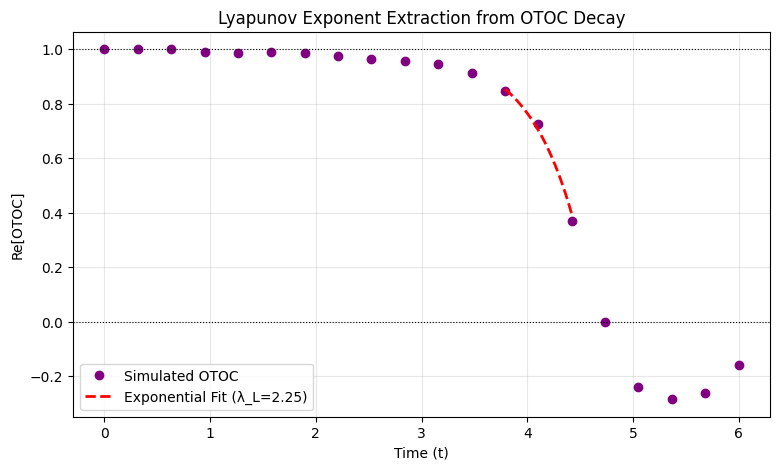

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Calculate the deviation from 1.0
# Ensure otoc_values is a numpy array
otoc_array = np.array(otoc_values)
deviation = 1.0 - otoc_array

# 2. Isolate the "Scrambling Window"
# We only want the steep drop, ignoring the flat delay and the bottom bounce
# Let's target the region where the OTOC falls between 0.9 and 0.1
valid_indices = np.where((otoc_array < 0.9) & (otoc_array > 0.1))[0]

if len(valid_indices) < 2:
    print("Not enough data points in the exponential decay region to fit a curve.")
    print("Try increasing the total time or the number of time points in your simulation.")
else:
    # Extract the relevant time and deviation data
    t_fit = time_points[valid_indices]
    dev_fit = deviation[valid_indices]

    # Take the natural logarithm: ln(Delta F) = lambda_L * t + C
    log_dev = np.log(dev_fit)

    # 3. Perform Linear Regression (Polyfit of degree 1)
    slope, intercept = np.polyfit(t_fit, log_dev, 1)
    lambda_L = slope

    print(f"=======================================")
    print(f"Extracted Quantum Lyapunov Exponent (\u03BB_L): {lambda_L:.4f}")
    print(f"=======================================")

    # 4. Plot the Fit against the Data
    plt.figure(figsize=(9, 5))

    # Plot original OTOC data
    plt.plot(time_points, otoc_array, marker='o', linestyle='', color='purple', label="Simulated OTOC")

    # Generate the fitted curve: F(t) = 1 - e^(lambda_L * t + intercept)
    t_continuous = np.linspace(t_fit[0], t_fit[-1], 100)
    fitted_curve = 1.0 - np.exp(lambda_L * t_continuous + intercept)

    # Plot the fit
    plt.plot(t_continuous, fitted_curve, linestyle='--', color='red', linewidth=2, label=f"Exponential Fit (\u03BB_L={lambda_L:.2f})")

    # Formatting
    plt.axhline(0, color='black', linestyle=':', linewidth=0.8)
    plt.axhline(1, color='black', linestyle=':', linewidth=0.8)
    plt.title("Lyapunov Exponent Extraction from OTOC Decay")
    plt.xlabel("Time (t)")
    plt.ylabel("Re[OTOC]")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()